<a href="https://colab.research.google.com/github/Tojiyevvd/SI/blob/main/16_topshiriq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

mavzu Kompyuter korish klasik usullar
opensivli yordamida tasvirlarni qayta ishlash filtrlash konturlarni ajratib olish tasvirdagi obektlarni aniqlash

In [ ]:
import cv2
import numpy as np
from  matplotlib import pyplot as plt

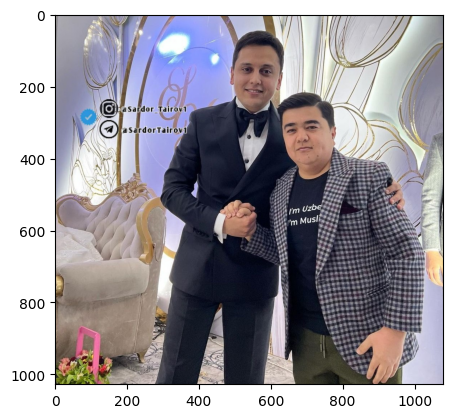

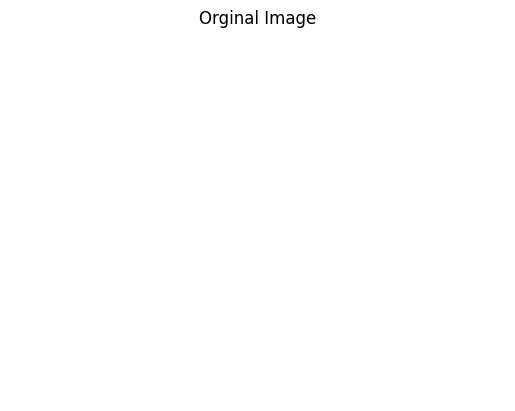

In [ ]:
img=cv2.imread('/content/IMG_20220327_215129_275.jpg')
#BGR->RGB
img_rgb =cv2.cvtColor(img,cv2.COLOR_BGR2RGB)#cv2.COLOR_BGR2RGB--->rang formatini ozgartirish kodi
plt.imshow(img_rgb)
plt.show()#rasmni ekranga chiqaradi
plt.axis('off') #koordinata oqlarini (x,y )ochiradi rasmni toza korinishida chiqaradi

plt.title("Orginal Image")
plt.show()

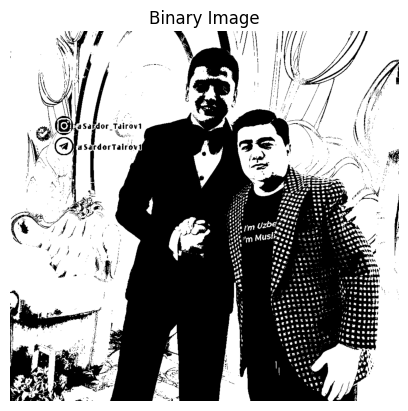

In [ ]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
_,thresh = cv2.threshold(gray,127,255,cv2.THRESH_BINARY)
plt.imshow(thresh,cmap='gray')
plt.title("Binary Image")
plt.axis('off')
plt.show()

Rasmni oq-qora (binary) qilish
cv2.COLOR_BGR2GRAY-->rangli rasmni grayscale (kulrang) ga o‘tkazadi.Har piksel 0–255 oralig‘ida bo‘ladi.

cv2.threshold-->chegaralash.

Parametrlar:

gray - kiruvchi rasm;
127 - threshold (chegara qiymat);
255 - maksimal qiymat (oq rang);
THRESH_BINARY - binary usul.
Qanday ishlaydi?

Har bir piksel tekshiriladi:

agar piksel > 127 → 255 (oq);

agar piksel ≤ 127 → 0 (qora).

Natija:

faqat 2 ta rang qoladi: qora (0) va oq (255).

OpenCV dagi cv2.threshold() funksiyasi 2 ta qiymat qaytaradi:

ret, thresh = cv2.threshold(...)

ret--> ishlatilgan threshold qiymati (masalan: 127) odatda bizga kerak bo‘lmaydi.
thresh--> natijaviy rasm (binary image) bu bizga kerak bo‘lgan asosiy natija.
_, thresh = ...

_ bu: “men bu qiymatni ishlatmayman” degani ya’ni ret ni e’tiborsiz qoldirib tashlab yuboryappiz.

plt.imshow--> natijaviy rasmni ko‘rsatadi.

cmap='gray' --> qora-oq ko‘rinishda chiqaradi.

Bu kod: rasmni yuklaydi,uni kulrangga o‘tkazadi,threshold orqali faqat qora va oq rangga ajratadi,natijani ko‘rsatadi.

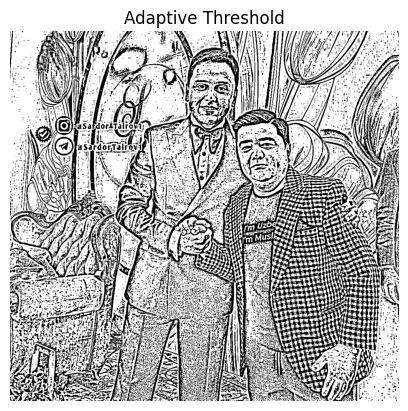

In [ ]:
adaptive = cv2.adaptiveThreshold(
    gray,255,
    cv2.ADAPTIVE_THRESH_MEAN_C,
    cv2.THRESH_BINARY,
    11,2
)
plt.imshow(adaptive,cmap='gray')
plt.title("Adaptive Threshold")
plt.axis('off')
plt.show()


Adaptive Threshold (yorug‘likka moslashuvchi)
cv2.adaptiveThreshold(...) --> bu funksiya oddiy thresholddan farqli ravishda har bir kichik hudud uchun alohida threshold hisoblaydi.

Parametrlar:

gray --> kiruvchi rasm (grayscale bo‘lishi shart).

255 --> maksimal qiymat,natijada oq rang = 255 bo‘ladi.

cv2.ADAPTIVE_THRESH_MEAN_C -->threshold hisoblash usuli. Bu usul har bir hududdagi piksellarning o‘rtacha qiymatini (mean) oladi va shunga qarab threshold qo‘yadi. Boshqa variant: ADAPTIVE_THRESH_GAUSSIAN_C (og‘irlik bilan hisoblaydi).

cv2.THRESH_BINARY --> natija turi:

piksel > threshold → oq;

piksel ≤ threshold → qora.

11 (block size) --> eng muhim parametrlardan biri.Rasm kichik bloklarga bo‘linadi (11×11)har blok uchun alohida threshold hisoblanadi.
2 (C qiymati)--> bu — kichik tuzatish (offset),hisoblangan thresholddan 2 ayiriladi. Bu natijani nozik sozlash uchun ishlatiladi.
threshold = mean - C

Oddiy threshold: butun rasmga 1 ta qiymat qo‘llaydi.

Adaptive threshold: har joyga alohida qiymat qo‘llaydi.

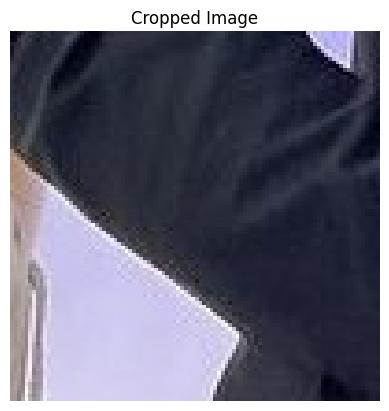

In [ ]:
crop = img[500:600,300:400]
plt.imshow(cv2.cvtColor(crop,cv2.COLOR_BGR2RGB))
plt.title("Cropped Image")
plt.axis('off')
plt.show()

Rasmni kesish (Cropping)
img[y1:y2, x1:x2]

Demak:

100:300 → y (balandlik) bo‘yicha;
200:400 → x (eni) bo‘yicha.
OpenCV’da indekslash: img[y, x]

E’tibor bering:

avval y (qator);
keyin x (ustun).
Rasmning quyidagi qismini:

yuqoridan: 100 px

pastgacha: 300 px

chapdan: 200 px

o‘nggacha: 400 px

Natija: rasmning o‘rtasidan bir bo‘lak.

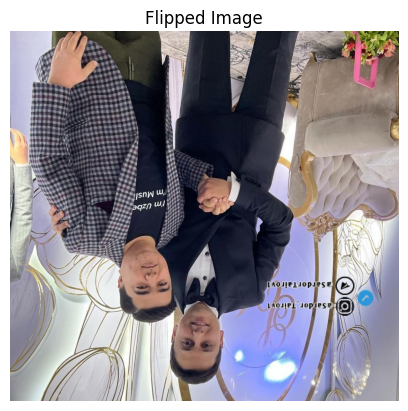

In [ ]:
flip  =cv2.flip(img, -1)
#cv2.flip-->rasmni  aylantirish(flip)yani rasmni akslantiradi( mirror effect)
#1->gorizantal flip (chap ong)
#0-->vertikal flip (yuqoridan pasga)
#-1--> har ikisini(gorizantal +vertikal)
plt.imshow(cv2.cvtColor(flip,cv2.COLOR_BGR2RGB))
plt.title("Flipped Image")
plt.axis('off')
plt.show()

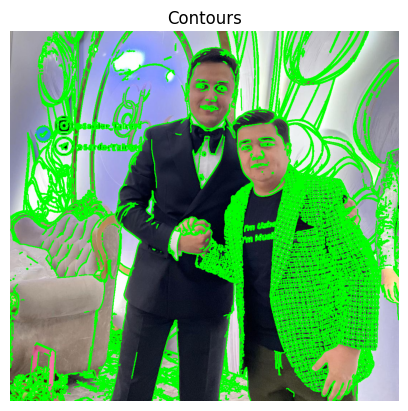

In [ ]:
edges = cv2.Canny(gray, 100,200)
contours,_ = cv2.findContours(edges,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
img_contour = img.copy()
cv2.drawContours(img_contour,contours,-1,(0,255,0),2)
plt.imshow(cv2.cvtColor(img_contour,cv2.COLOR_BGR2RGB))
plt.title("Contours")
plt.axis('off')
plt.show()


Kontur aniqlash (Contours)
cv2.Canny -->rasmda chegaralarni (edges) aniqlaydi.

Parametrlar:

gray - kulrang rasm;

100 - past threshold;

200 - yuqori threshold.

Natija: faqat chiziqlar (konturlar) qoladi, fon yo‘qoladi.

cv2.findContours -->rasm ichidagi shakllar chegarasini topadi,har bir obyekt alohida kontur sifatida olinadi.

Parametrlar:

edges --> kiruvchi rasm (odatda binary yoki edge image).

cv2.RETR_TREE --> konturlarni qanday olish.Barcha konturlarni oladi ularning ichki tuzilishini (hierarchy) ham saqlaydi.

cv2.CHAIN_APPROX_SIMPLE --> kontur nuqtalarini soddalashtiradi,ortiqcha nuqtalarni olib tashlaydi tezlikni oshiradi.

Ikkinchi qiymat (hierarchy) va biz uni ishlatmayapmiz.Shuning uchun _ belgisi bilan tashlab yuboramiz.

img.copy() --> asl rasmni o‘zgartirmaslik uchun nusxa olinadi.

cv2.drawContours --> topilgan konturlarni rasm ustiga chizadi.

Parametrlar:

img_contour → rasm;
contours → konturlar ro‘yxati;
-1 → barcha konturlarni chizish;
(0,255,0) → yashil rang (BGR);
2 → chiziq qalinligi.

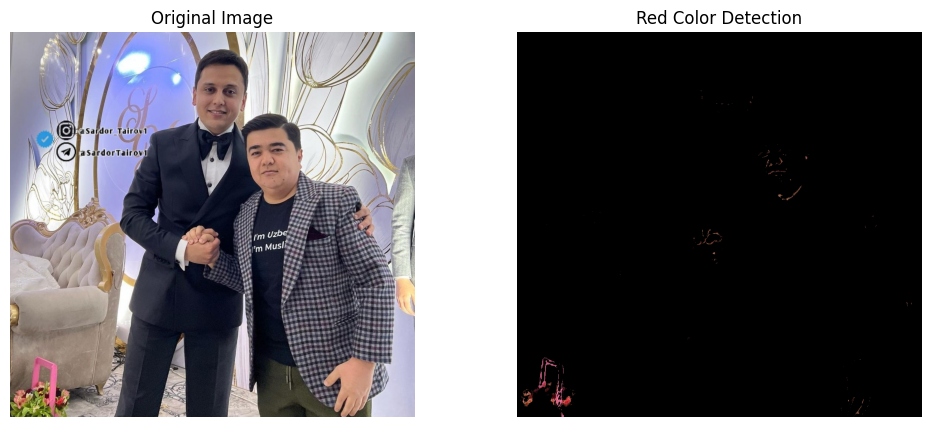

In [ ]:
#Rang bo‘yicha filtr (Color Detection):

img = cv2.imread('/content/IMG_20220327_215129_275.jpg')
# BGR → HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
# Qizil rang diapazoni (2 ta interval bo‘ladi!)
lower_red1 = np.array([0,120,70])
upper_red1 = np.array([10,255,255])
lower_red2 = np.array([170,120,70])
upper_red2 = np.array([180,255,255])
# Maskalar
mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
#inRange() → berilgan diapazonga tushgan piksellarni tanlaydi.Natija: mos kelsa → oq (255),mos kelmasa → qora (0)
# Ikkalasini qo‘shish
mask = mask1 + mask2
# Natija (faqat qizil ranglar qoladi)
result = cv2.bitwise_and(img, img, mask=mask)
#cv2.bitwise_and-->faqat maska ichidagi (qizil) joylarni qoldiradi,qolgan hamma ranglar yo‘qoladi (qora bo‘ladi)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Red Color Detection")
plt.axis('off')

plt.show()

In [ ]:
#morfologik operatsiyalar:
kernel = np.ones((5,5), np.uint8)
